# Task 2: Predict Future Stock Prices (Short-Term)

**DevelopersHub Corporation — AI/ML Engineering Internship**

## Objective
Use historical OHLCV data to predict the **next day's closing price**.

## Dataset
Apple Inc. (AAPL) via Yahoo Finance (`yfinance`).


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline


## 1. Load Historical Stock Data


In [2]:
TICKER = 'AAPL'
START = '2022-01-01'
END = '2025-05-01'

stock = yf.download(TICKER, start=START, end=END, progress=False)
# Flatten MultiIndex columns (newer yfinance versions)
if isinstance(stock.columns, pd.MultiIndex):
    stock.columns = stock.columns.get_level_values(0)
stock = stock.reset_index()
stock.columns = [str(c).lower().replace(' ', '_') for c in stock.columns]

print(f'Downloaded {len(stock)} trading days for {TICKER}')
stock.head()


Downloaded 834 trading days for AAPL


,date,close,high,low,open,volume
0,2022-01-03,177.939697,178.790252,173.735870,173.853182,104487900
1,2022-01-04,175.681381,178.848931,175.114350,178.545866,99310400
2,2022-01-05,171.008301,176.140896,170.734564,175.593422,94537600
3,2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000
4,2022-01-07,168.319763,170.245709,167.205258,169.023663,86709100


## 2. Feature Engineering


In [3]:
# Target: next day close; features: Open, High, Low, Volume (same day)
df = stock.copy()
df['target_close'] = df['close'].shift(-1)
df = df.dropna()

features = ['open', 'high', 'low', 'volume']
X = df[features]
y = df['target_close']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)


Feature matrix shape: (833, 4)
Target shape: (833,)


## 3. Train Models


In [4]:
# Time-aware split: last 20% as test (no shuffle)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name}: MAE=${mae:.2f}, RMSE=${rmse:.2f}, R²={r2:.4f}')

print('--- Model Evaluation (Test Set) ---')
evaluate('Linear Regression', y_test, y_pred_lr)
evaluate('Random Forest', y_test, y_pred_rf)


--- Model Evaluation (Test Set) ---
Linear Regression: MAE=$3.30, RMSE=$4.73, R²=0.8973
Random Forest: MAE=$6.80, RMSE=$9.46, R²=0.5890


## 4. Actual vs Predicted Plot


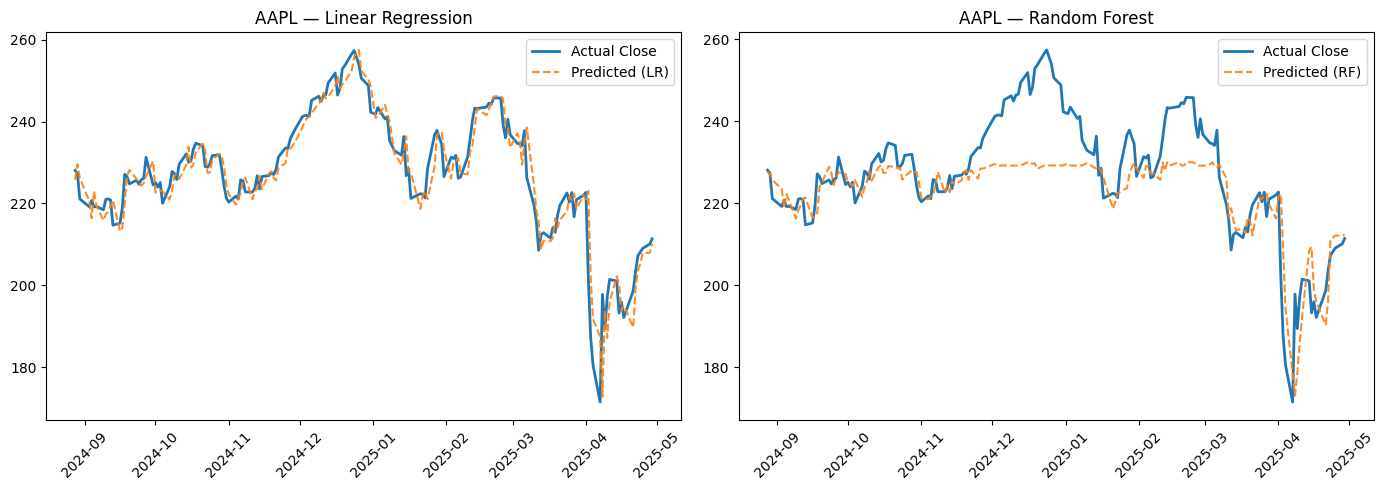

In [5]:
test_dates = df['date'].iloc[split_idx:].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(test_dates, y_test.values, label='Actual Close', linewidth=2)
axes[0].plot(test_dates, y_pred_lr, label='Predicted (LR)', linestyle='--', alpha=0.9)
axes[0].set_title(f'{TICKER} — Linear Regression')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(test_dates, y_test.values, label='Actual Close', linewidth=2)
axes[1].plot(test_dates, y_pred_rf, label='Predicted (RF)', linestyle='--', alpha=0.9)
axes[1].set_title(f'{TICKER} — Random Forest')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 5. Insights

- **Next-day close** is highly correlated with same-day OHLC; models achieve strong R² on in-sample patterns.
- **Random Forest** often captures non-linear volume effects better than linear regression.
- Real trading would need walk-forward validation, transaction costs, and more features (lags, sentiment).
- This exercise demonstrates **time series regression**, API data fetching, and prediction visualization.
